In [8]:
import pandas as pd
import numpy as np

import tubesml as tml

import matplotlib.pyplot as plt
%matplotlib inline

from source.aggregated_stats import process_details, full_stats
from source.add_info import add_seed
from source.make_train_test import make_teams_target, make_training_data


In [3]:
men_reg = pd.read_csv('data/march-machine-learning-mania-2026/MRegularSeasonDetailedResults.csv')
men_reg = process_details(men_reg)
men_reg = full_stats(men_reg)

men_reg.head()

,Season,TeamID,Ast,Ast_TO_ratio,Ast_TO_ratio_diff,Ast_diff,Away,Blk,Blk_diff,DR,...,FGM_perc,FGM2_perc,FGM3_perc,FT_perc,FGM_no_ast_perc,True_shooting_perc,Opp_True_shooting_perc,Eff_shooting_perc,Opp_eff_shooting_perc,OT_win_perc
0,2003,1102,13.000000,1.375064,0.605190,3.857143,0.107143,1.785714,0.214286,16.821429,...,0.481149,0.596987,0.375643,0.651357,0.320896,0.605015,0.559937,0.579443,0.510522,0.00
1,2003,1103,15.222222,1.324485,0.263219,-0.259259,0.148148,2.333333,-0.518519,19.925926,...,0.486074,0.545624,0.338710,0.736390,0.439291,0.585912,0.585422,0.534814,0.545809,0.75
2,2003,1104,12.107143,0.992390,0.044657,0.428571,0.142857,3.785714,0.607143,23.928571,...,0.420362,0.473684,0.320144,0.709898,0.496285,0.521831,0.515522,0.475953,0.476190,1.00
3,2003,1105,14.538462,0.861957,-0.074315,-1.269231,0.076923,2.076923,-2.115385,23.115385,...,0.395755,0.411488,0.364815,0.705986,0.403785,0.503801,0.549557,0.457241,0.511089,0.00
4,2003,1106,11.678571,0.723189,-0.129575,-0.107143,0.178571,3.142857,-0.035714,23.857143,...,0.423773,0.460152,0.346154,0.646421,0.501524,0.508613,0.505494,0.479005,0.451505,1.00


In [5]:
men_reg = add_seed('data/march-machine-learning-mania-2026/MNCAATourneySeeds.csv', men_reg)

In [7]:
men_target_data = pd.read_csv('data/march-machine-learning-mania-2026/MNCAATourneyCompactResults.csv')
men_target_data = make_teams_target(men_target_data, "men")

In [9]:
men_training = make_training_data(men_reg, men_target_data)
men_training  = men_training[men_training.DayNum >= 136]  # remove pre tourney 

men_training.head()

,Season,DayNum,Team1,Team2,target,target_points,T1_Loc,T2_Loc,ID,T1_Ast,...,delta_FT_perc,delta_FGM_no_ast_perc,delta_True_shooting_perc,delta_Opp_True_shooting_perc,delta_Eff_shooting_perc,delta_Opp_eff_shooting_perc,delta_OT_win_perc,delta_Seed,delta_off_edge,delta_def_edge
1,2003,136,1112,1436,1,29,0,0,2003_1112_1436,17.642857,...,0.043580,-0.009639,0.029586,-0.024490,0.023279,-0.021080,0.500000,-15.0,15.296992,11.161959
2,2003,136,1113,1272,1,13,0,0,2003_1113_1272,15.551724,...,0.016122,0.060936,0.023379,0.043313,0.017069,0.041206,1.000000,3.0,16.306520,6.912553
3,2003,136,1141,1166,1,6,0,0,2003_1141_1166,15.620690,...,0.072864,-0.000726,0.024266,0.028571,0.001197,0.021989,-1.000000,5.0,17.037470,12.485948
4,2003,136,1143,1301,1,2,0,0,2003_1143_1301,16.000000,...,-0.084846,0.017620,-0.027432,-0.019602,-0.010679,-0.002899,-0.666667,-1.0,4.086544,8.747367
5,2003,136,1140,1163,0,-5,0,0,2003_1140_1163,13.419355,...,0.078796,-0.029044,0.028961,0.038428,0.005684,0.028207,-1.000000,7.0,13.738997,12.639235


# Winning target

In [33]:
target = "target"
col_to_use = [c for c in men_training if "target" not in c and c != "ID" and "region" not in c] + [target]

df = men_training[col_to_use].copy()

df.head()

,Season,DayNum,Team1,Team2,T1_Loc,T2_Loc,T1_Ast,T1_Ast_TO_ratio,T1_Ast_TO_ratio_diff,T1_Ast_diff,...,delta_FGM_no_ast_perc,delta_True_shooting_perc,delta_Opp_True_shooting_perc,delta_Eff_shooting_perc,delta_Opp_eff_shooting_perc,delta_OT_win_perc,delta_Seed,delta_off_edge,delta_def_edge,target
1,2003,136,1112,1436,0,0,17.642857,1.293499,0.268768,2.178571,...,-0.009639,0.029586,-0.024490,0.023279,-0.021080,0.500000,-15.0,15.296992,11.161959,1
2,2003,136,1113,1272,0,0,15.551724,1.203251,0.234365,1.482759,...,0.060936,0.023379,0.043313,0.017069,0.041206,1.000000,3.0,16.306520,6.912553,1
3,2003,136,1141,1166,0,0,15.620690,0.876120,0.085721,3.827586,...,-0.000726,0.024266,0.028571,0.001197,0.021989,-1.000000,5.0,17.037470,12.485948,1
4,2003,136,1143,1301,0,0,16.000000,1.223081,0.068821,-0.034483,...,0.017620,-0.027432,-0.019602,-0.010679,-0.002899,-0.666667,-1.0,4.086544,8.747367,1
5,2003,136,1140,1163,0,0,13.419355,1.089313,0.287916,2.645161,...,-0.029044,0.028961,0.038428,0.005684,0.028207,-1.000000,7.0,13.738997,12.639235,0


In [34]:
to_drop = ["delta_def_rating_diff", "delta_impact_diff", "T1_def_rating_diff", "T2_def_rating_diff"]
df = df.drop(to_drop, axis=1)

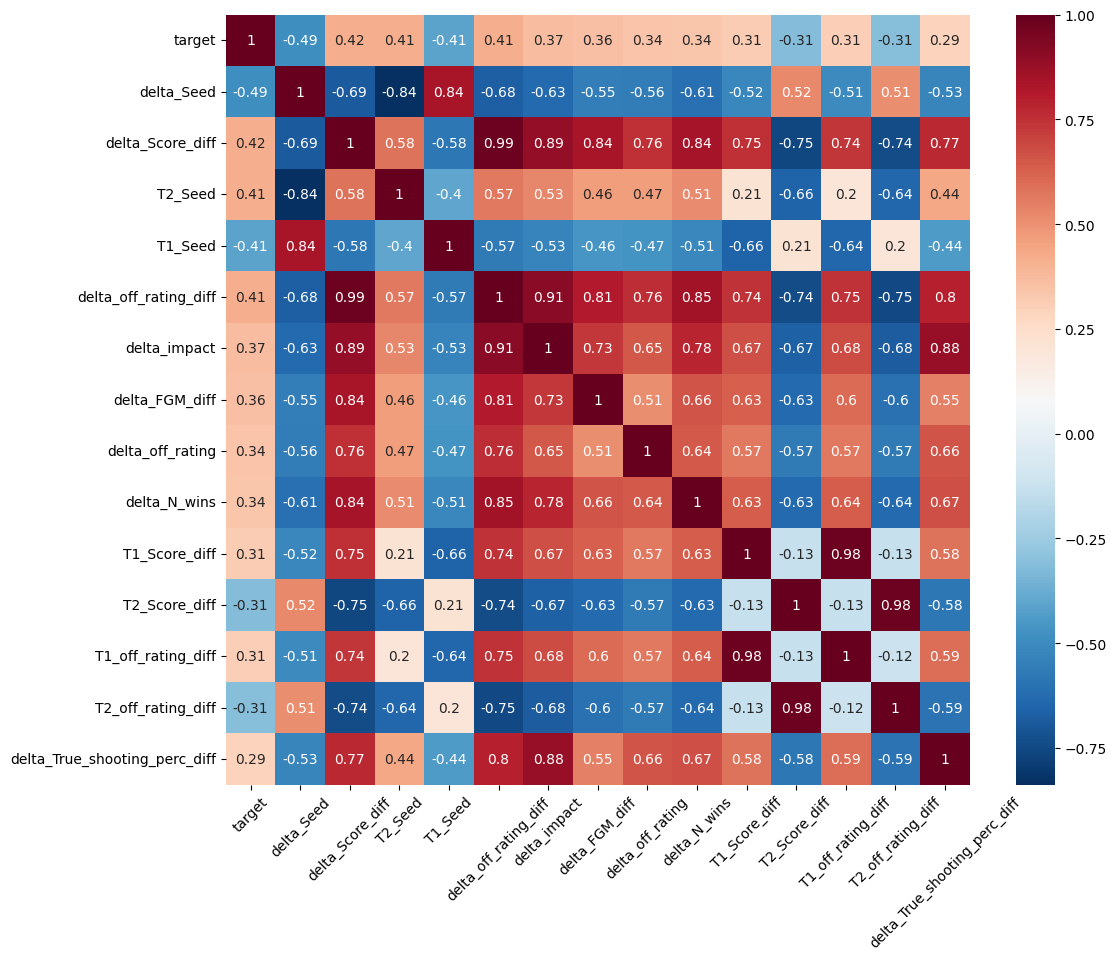

In [35]:
high_corr = tml.plot_correlations(data=df, target=target, limit=15, annot=True)

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN be

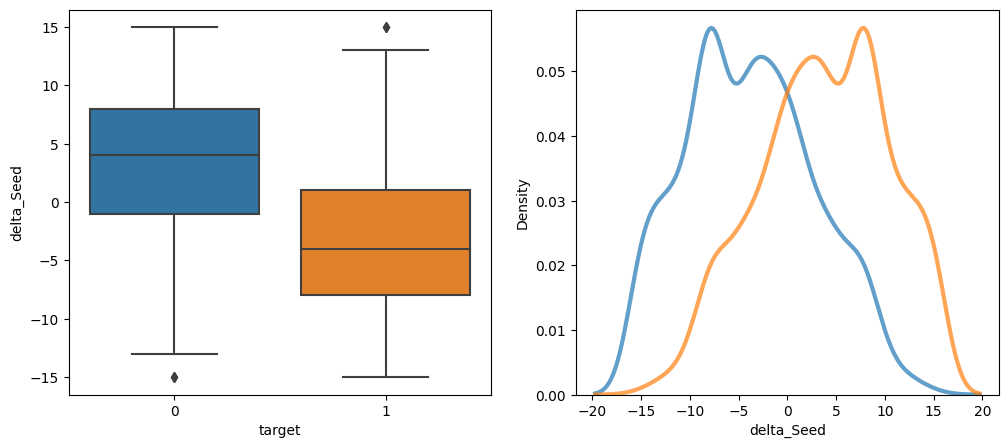

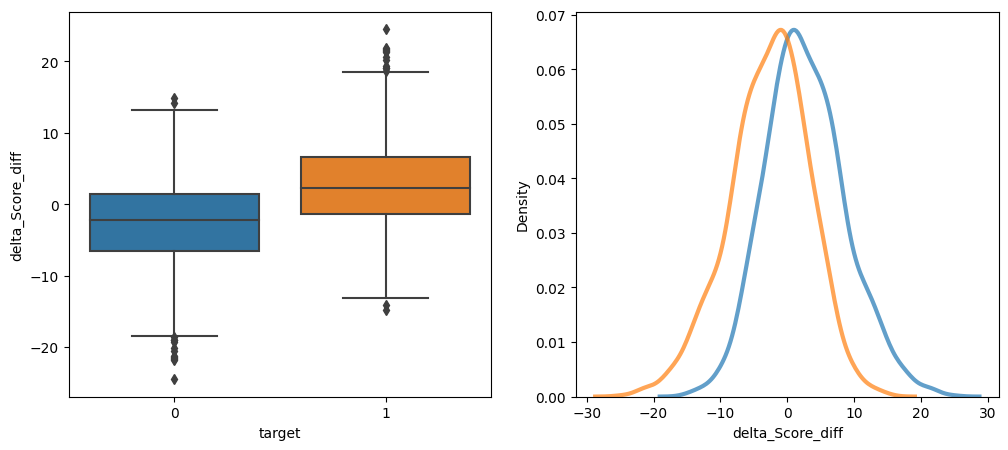

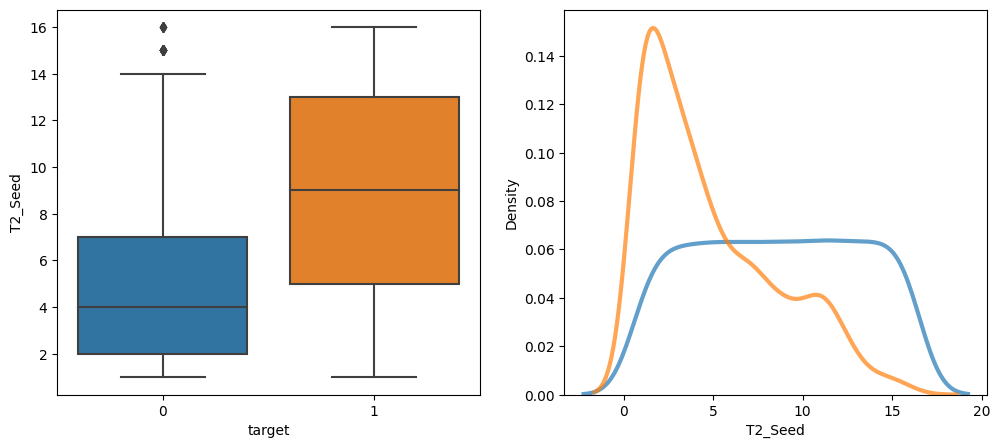

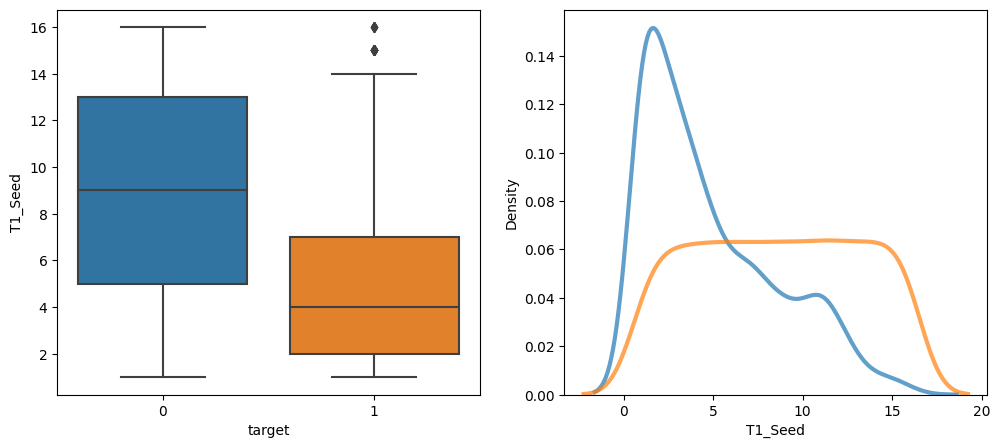

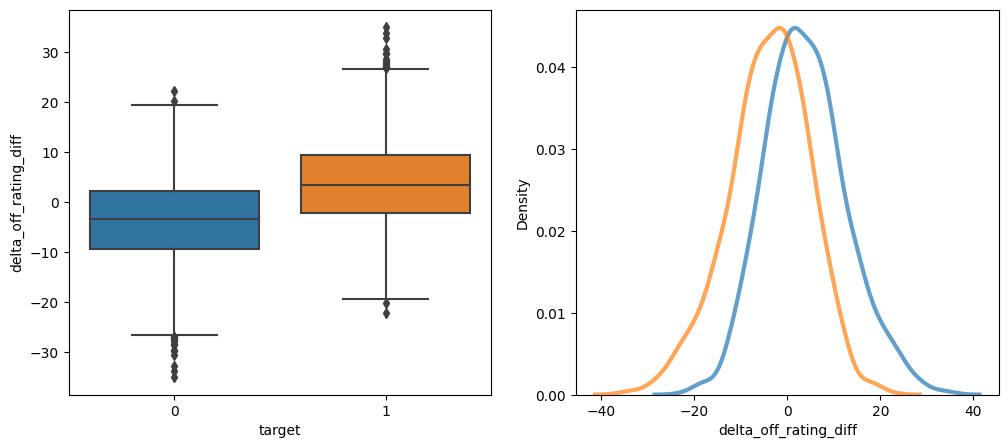

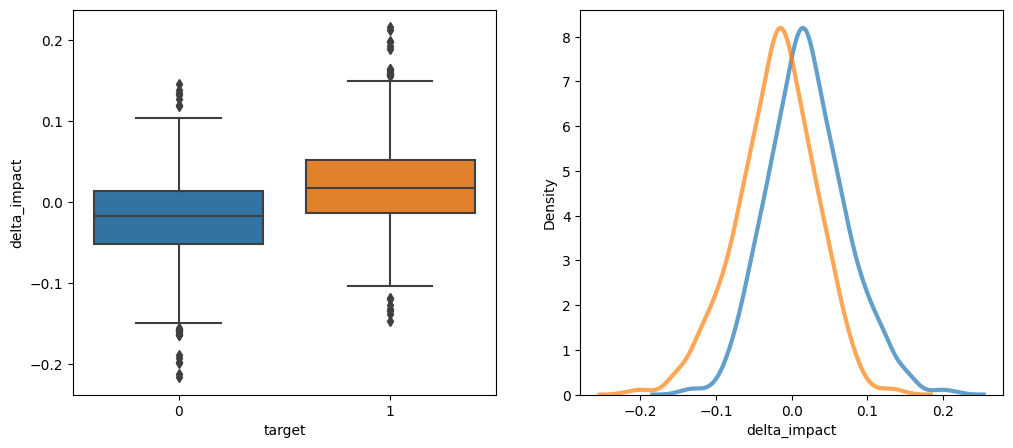

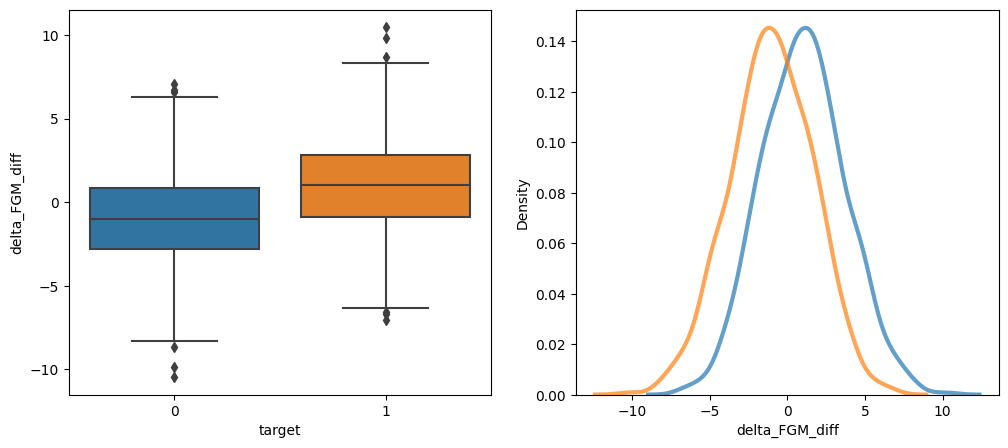

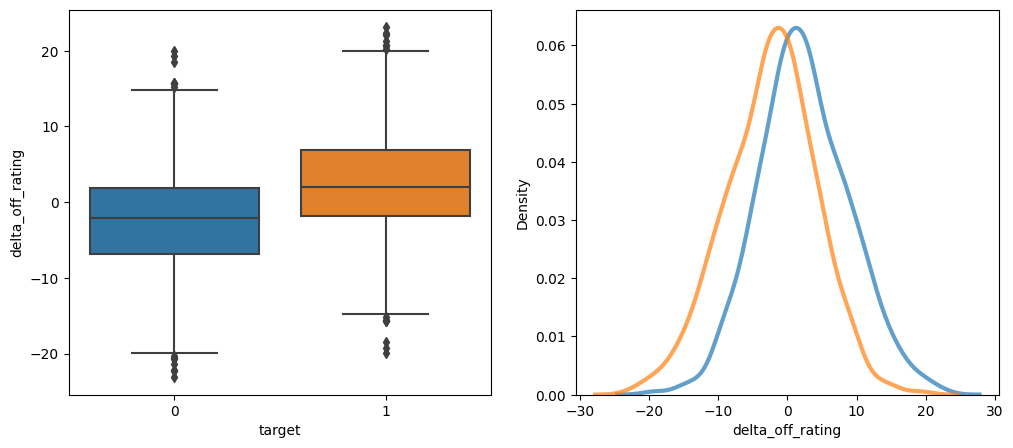

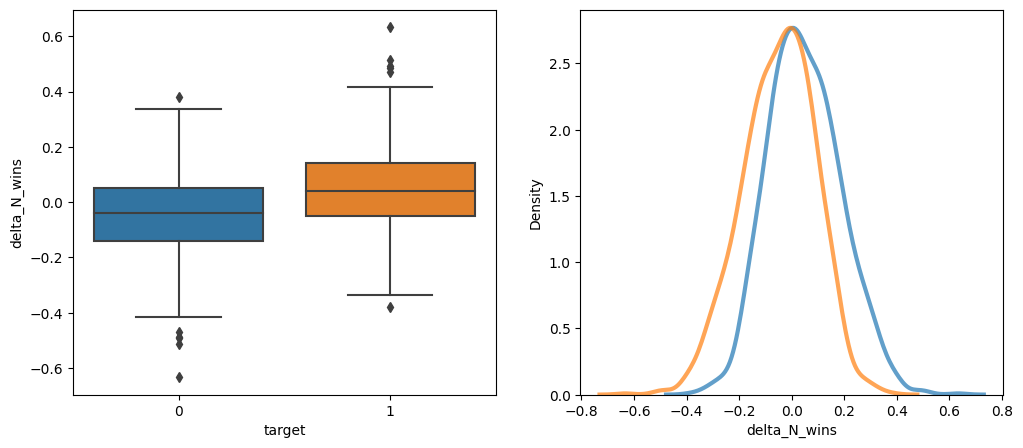

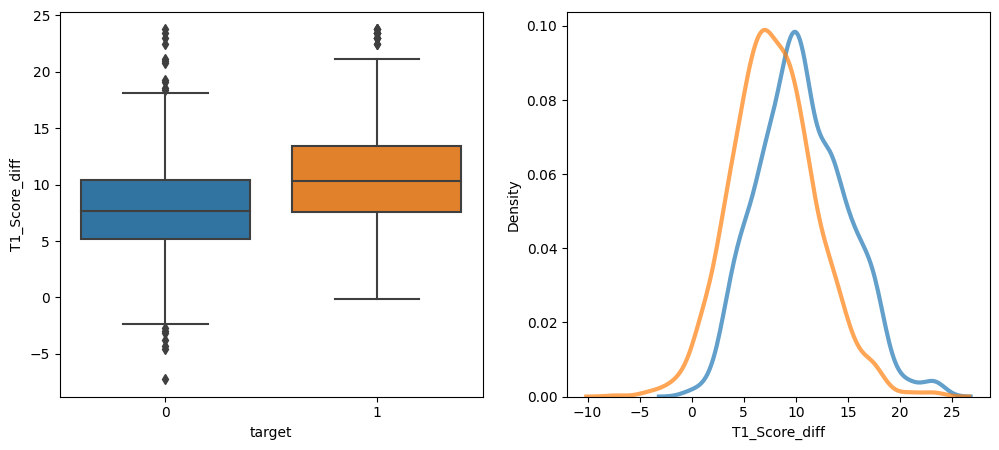

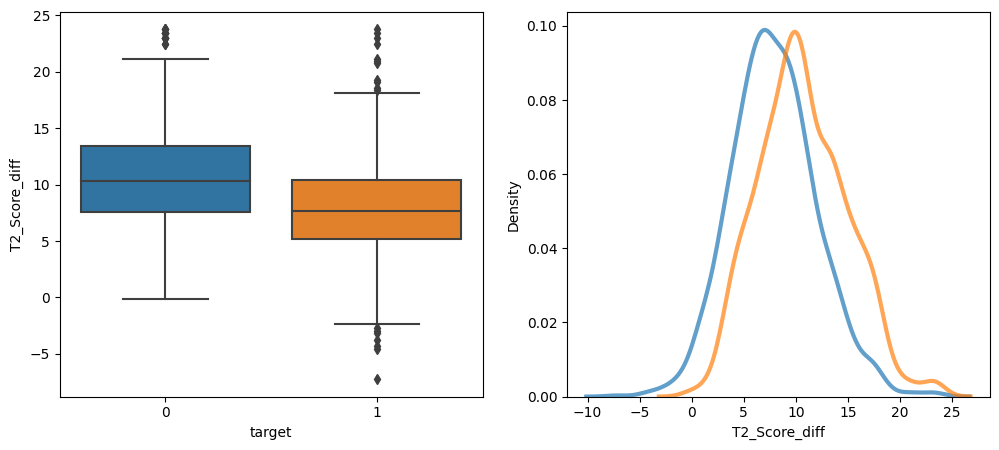

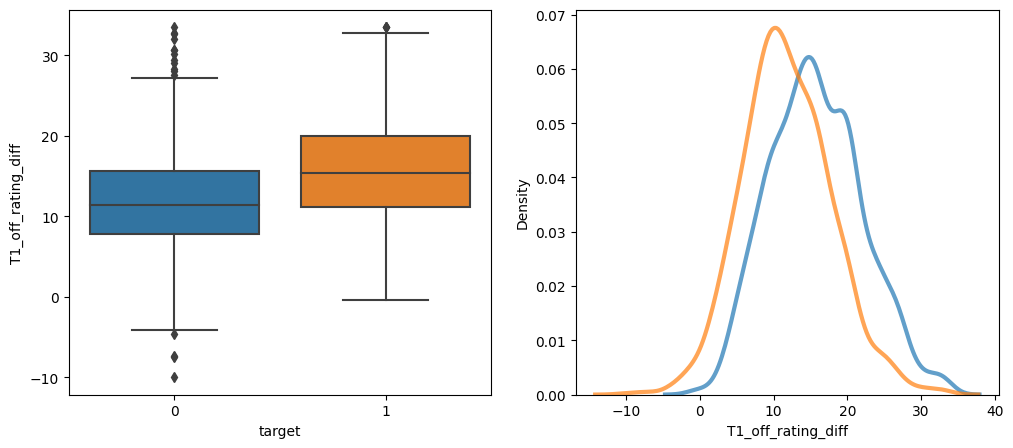

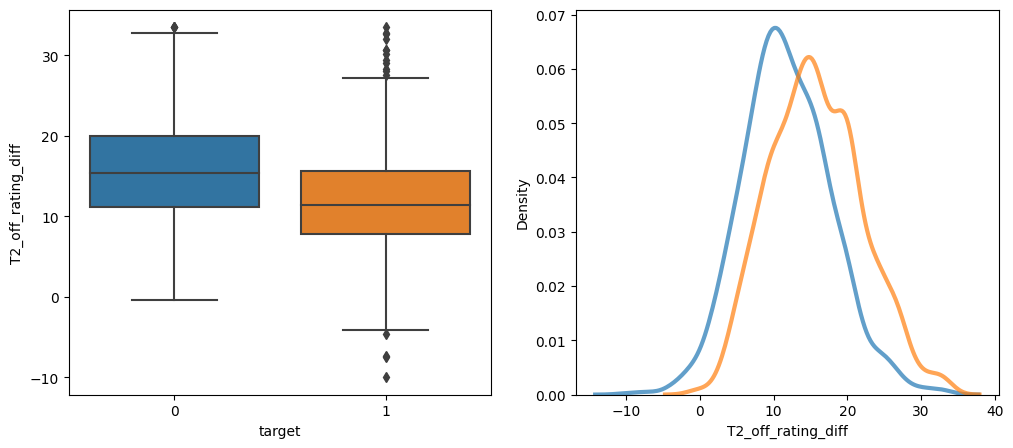

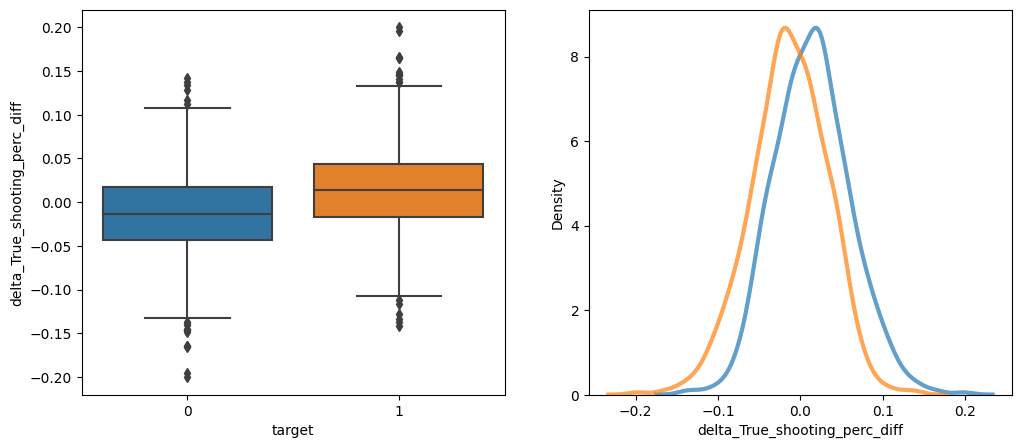

In [41]:
for col in high_corr.index:
    if col == target:
        continue
    tml.segm_target(data=df, cat=target, target=col)

# Point difference

In [43]:
target = "target_points"
col_to_use = [c for c in men_training if "target" not in c and c != "ID" and "region" not in c] + [target]

df = men_training[col_to_use].copy()
to_drop = ["delta_def_rating_diff", "delta_impact_diff", "T1_def_rating_diff", "T2_def_rating_diff"]
df = df.drop(to_drop, axis=1)

df.head()

,Season,DayNum,Team1,Team2,T1_Loc,T2_Loc,T1_Ast,T1_Ast_TO_ratio,T1_Ast_TO_ratio_diff,T1_Ast_diff,...,delta_FGM_no_ast_perc,delta_True_shooting_perc,delta_Opp_True_shooting_perc,delta_Eff_shooting_perc,delta_Opp_eff_shooting_perc,delta_OT_win_perc,delta_Seed,delta_off_edge,delta_def_edge,target_points
1,2003,136,1112,1436,0,0,17.642857,1.293499,0.268768,2.178571,...,-0.009639,0.029586,-0.024490,0.023279,-0.021080,0.500000,-15.0,15.296992,11.161959,29
2,2003,136,1113,1272,0,0,15.551724,1.203251,0.234365,1.482759,...,0.060936,0.023379,0.043313,0.017069,0.041206,1.000000,3.0,16.306520,6.912553,13
3,2003,136,1141,1166,0,0,15.620690,0.876120,0.085721,3.827586,...,-0.000726,0.024266,0.028571,0.001197,0.021989,-1.000000,5.0,17.037470,12.485948,6
4,2003,136,1143,1301,0,0,16.000000,1.223081,0.068821,-0.034483,...,0.017620,-0.027432,-0.019602,-0.010679,-0.002899,-0.666667,-1.0,4.086544,8.747367,2
5,2003,136,1140,1163,0,0,13.419355,1.089313,0.287916,2.645161,...,-0.029044,0.028961,0.038428,0.005684,0.028207,-1.000000,7.0,13.738997,12.639235,-5


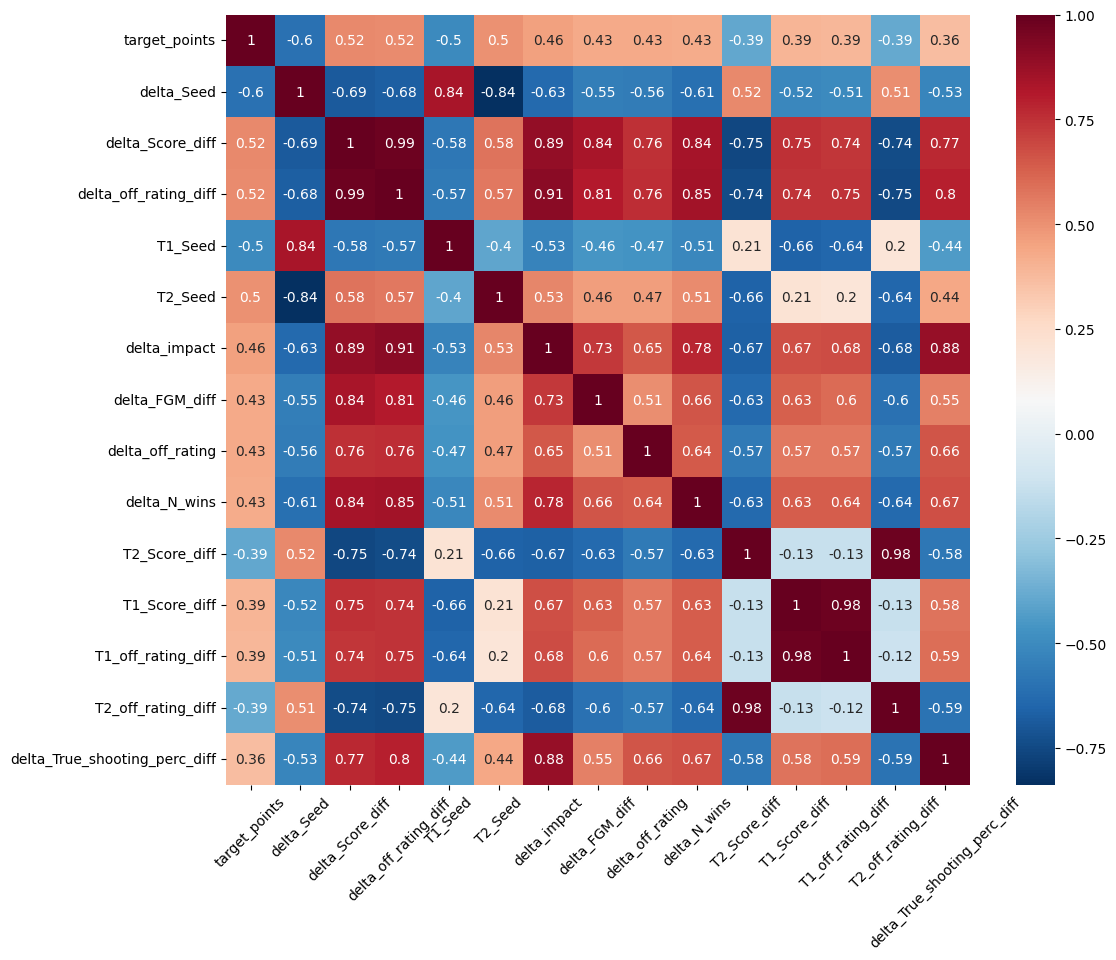

In [44]:
high_corr = tml.plot_correlations(data=df, target=target, limit=15, annot=True)

                               delta_Seed  delta_Score_diff  \
delta_Seed                       1.000000         -0.692387   
delta_Score_diff                -0.692387          1.000000   
delta_off_rating_diff           -0.675293          0.985560   
T1_Seed                          0.837555         -0.579912   
T2_Seed                         -0.837555          0.579912   
delta_impact                    -0.633803          0.892043   
delta_FGM_diff                  -0.551671          0.839874   
delta_off_rating                -0.559289          0.755908   
delta_N_wins                    -0.614498          0.842153   
T2_Score_diff                    0.521359         -0.752987   
T1_Score_diff                   -0.521359          0.752987   
T1_off_rating_diff              -0.505055          0.737104   
T2_off_rating_diff               0.505055         -0.737104   
delta_True_shooting_perc_diff   -0.525334          0.772687   
target_points                   -0.602123          0.52

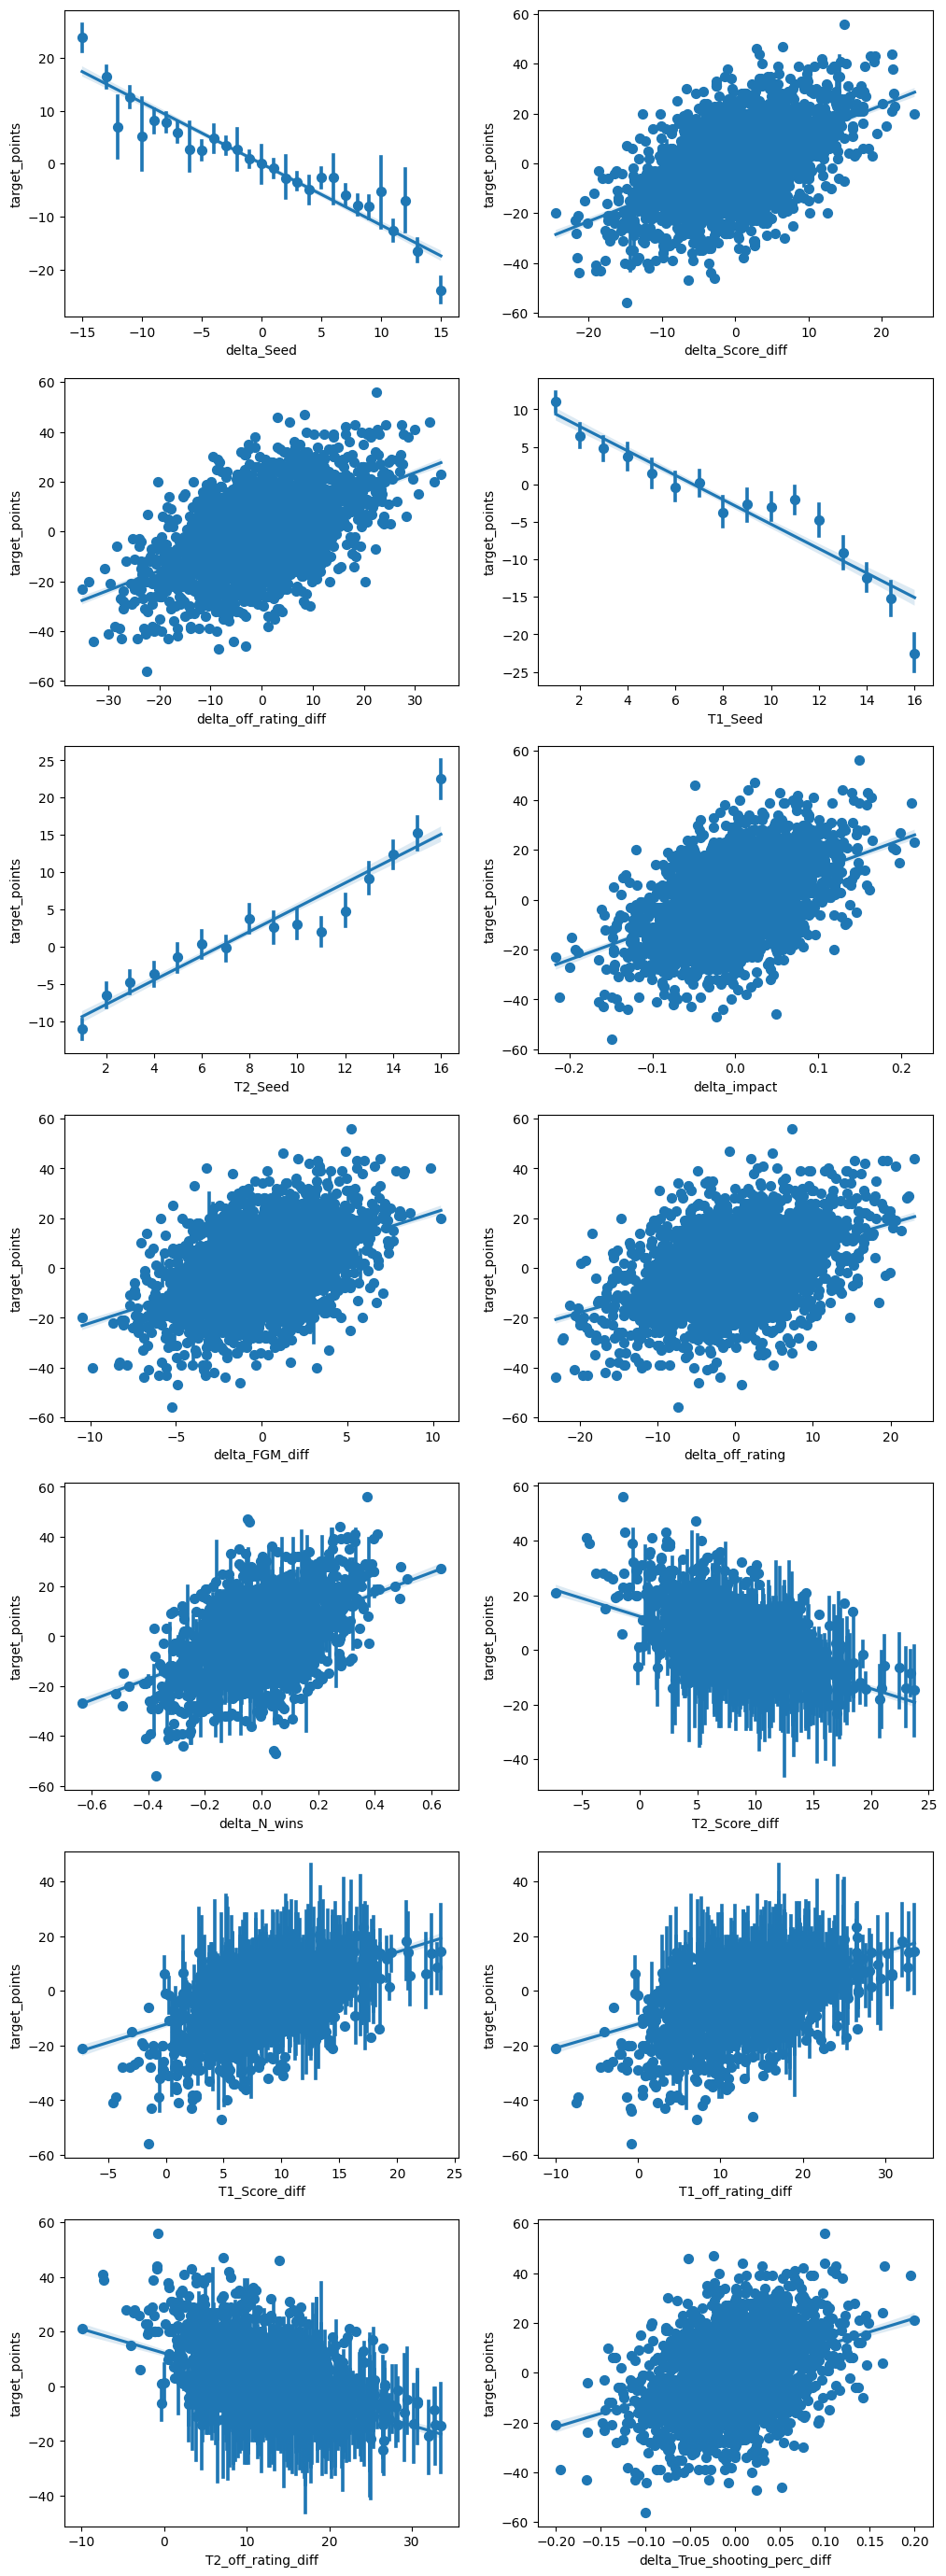

In [46]:
tml.corr_target(data=df, target=target, cols=[c for c in high_corr.index if c != target], x_estimator=np.mean)